**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

 **UPLOAD DATASET**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


**LOAD DATASET**

In [3]:
df = pd.read_csv('Mall_Customers.csv')

# show first 5 rows
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**DATASET INFORMATION**

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


**CHECK MISSING VALUES**

In [6]:
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**SELECT FEATURES**

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**DATA PREPROCESSING**

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**FIND BEST CLUSTERS**

In [9]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

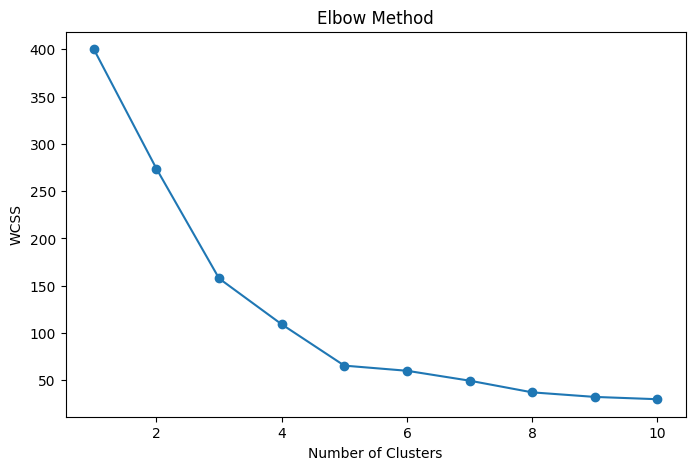

In [10]:
# Elbow Method Graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

**APPLY K-MEANS**

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

**VISUALIZE CLUSTERS**

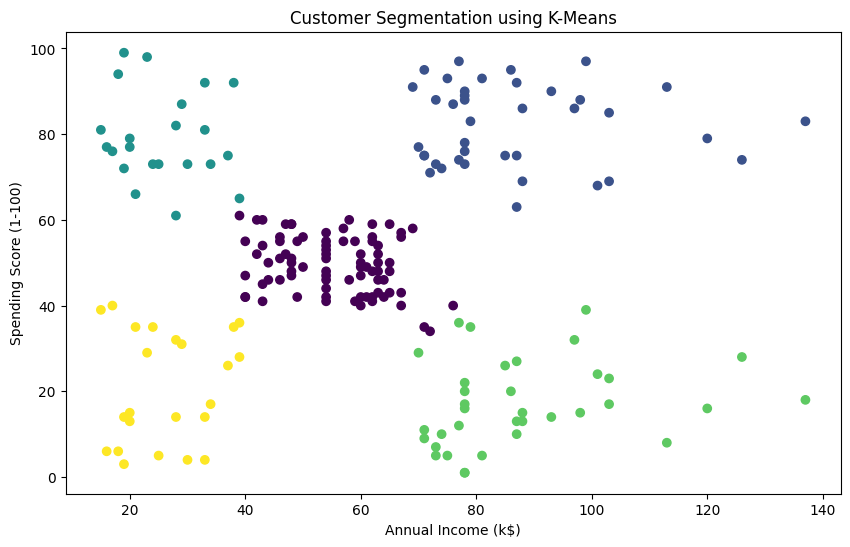

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')

plt.show()

**CUSTOMER SEGMENTS**

In [13]:
print("\nCUSTOMER SEGMENTS")
print(df[['CustomerID', 'Cluster']].head(20))


CUSTOMER SEGMENTS
    CustomerID  Cluster
0            1        4
1            2        2
2            3        4
3            4        2
4            5        4
5            6        2
6            7        4
7            8        2
8            9        4
9           10        2
10          11        4
11          12        2
12          13        4
13          14        2
14          15        4
15          16        2
16          17        4
17          18        2
18          19        4
19          20        2


**CLUSTER INSIGHTS**

In [14]:
cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("\nCLUSTER SUMMARY")
print(cluster_summary)


CLUSTER SUMMARY
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


**BUSINESS INSIGHTS**

1. Customers are divided into different groups based on their income and spending behavior.

2. Cluster with high income and high spending score represents premium customers.
   These customers are very valuable for the business.

3. Customers with high income but low spending can be targeted using discounts,
   membership offers, and personalized marketing.

4. Customers with low income and low spending are budget-focused customers.

5. High spending customers should receive special attention because they contribute
   more to business revenue.

6. Customer segmentation helps businesses improve marketing strategies
   and understand customer behavior better.